In [4202]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.image as img
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, log_loss



In [4203]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")
test_outcome = pd.read_csv("data/gender_submission.csv")



test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4204]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4205]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4206]:
plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams.update({"font.size": 14})

train_data.Pclass = [str(i) for i in train_data.Pclass]

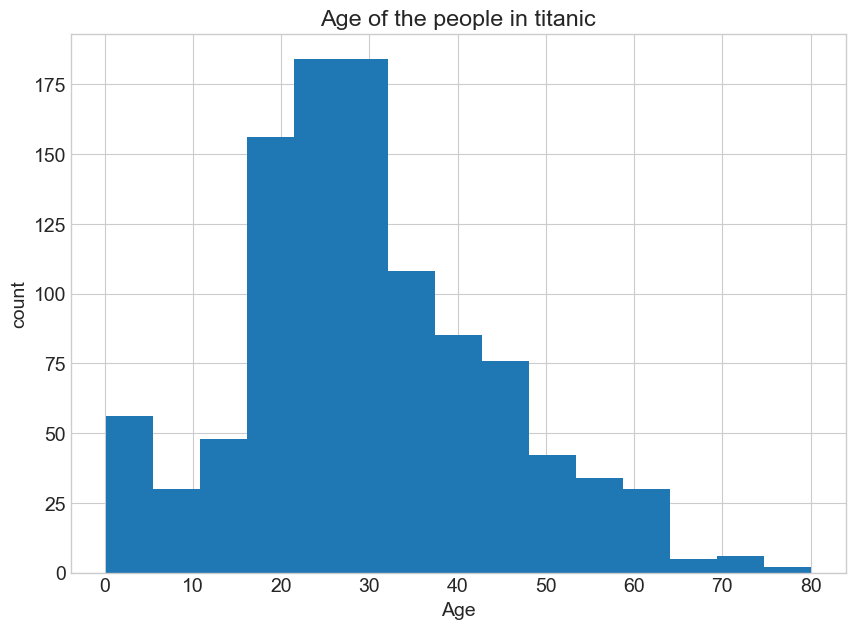

In [4207]:
plt.figure(figsize=(10,7))


plt.hist(pd.concat([train_data.Age, test_data.Age]), bins=15)

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.show()

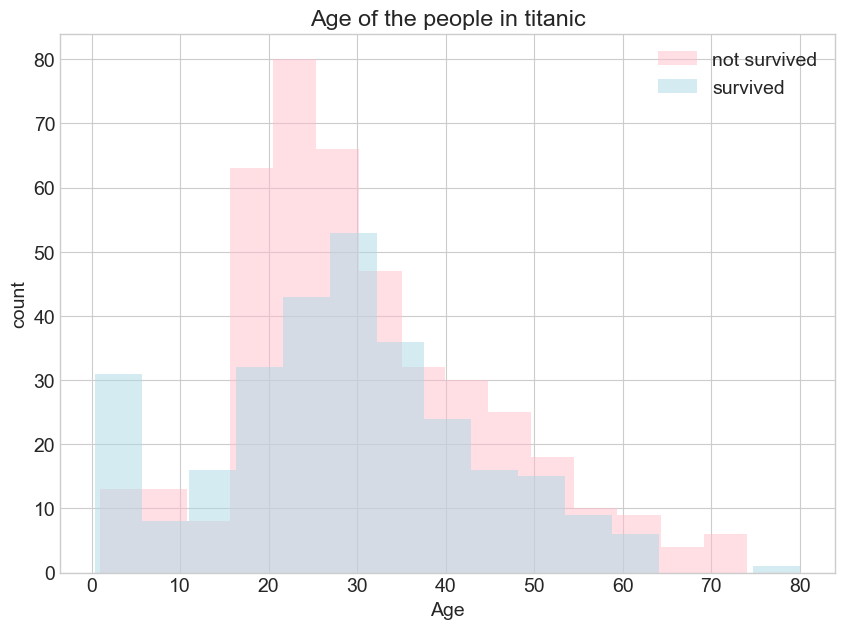

In [4208]:
plt.figure(figsize=(10,7))

plt.hist(train_data.loc[train_data.Survived == 0]["Age"], alpha=0.5, bins=15, color="pink", label="not survived")
plt.hist(train_data.loc[train_data.Survived == 1]["Age"], alpha=0.5, bins=15, color="lightblue",label="survived")

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.legend()
plt.show()

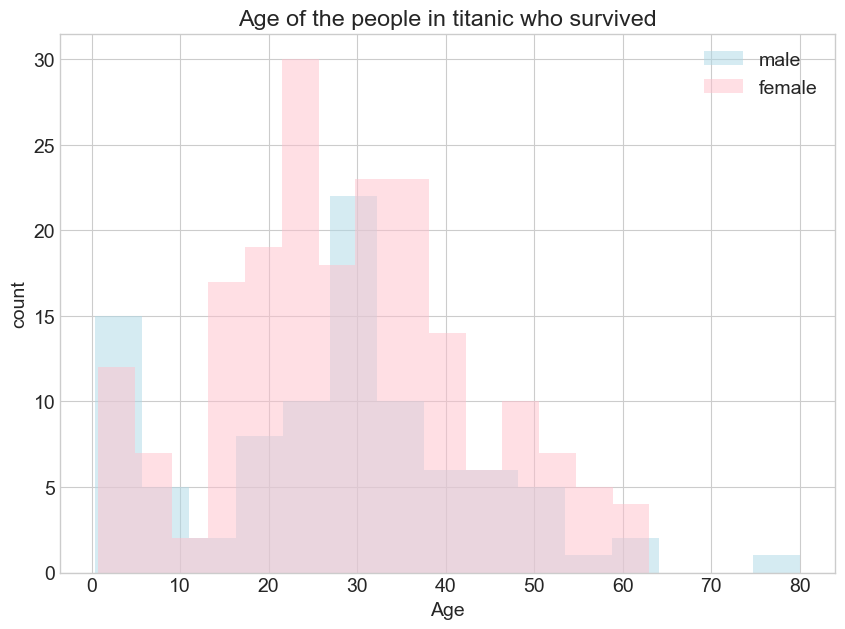

In [4209]:
plt.figure(figsize=(10,7))

plt.hist(train_data.loc[(train_data.Survived == 1) & (train_data.Sex == "male")]["Age"], alpha=0.5, bins=15, color="lightblue", label="male")
plt.hist(train_data.loc[(train_data.Survived == 1) & (train_data.Sex == "female")]["Age"], alpha=0.5, bins=15, color="pink",label="female")


plt.title("Age of the people in titanic who survived")
plt.xlabel("Age")
plt.ylabel("count")

plt.legend()
plt.show()

In [4210]:
# predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
# outcome = 'Survived'

# train_data = train_data.dropna()

# X = pd.get_dummies(train_data[predictors], drop_first=True)
# y = train_data[outcome]

# model_simple = LogisticRegression()
# model_simple.fit(X,y,)

def print_metrics(y_true,y_pred,title):
    print(f"Metrics of {title}")
    print("-----------------------------")
    print(f"Accuracy: {accuracy_score(y_true,y_pred)}")
    print(f"Precision: {precision_score(y_true,y_pred)}")
    print(f"Recall: {recall_score(y_true,y_pred)}")
    print(f"Logloss: {log_loss(y_true,y_pred)}")
    print(f"ROC-AUC: {roc_auc_score(y_true,y_pred)}")


# test_data.Pclass = [str(i) for i in test_data.Pclass]

# X = pd.get_dummies(test_data[predictors], drop_first=True)
# y = test_outcome.Survived

# deleted_index = set(y.index) - set(X.dropna().index)

# y.drop(deleted_index, inplace=True)
# X.dropna(inplace=True)

In [4211]:
# y_pred = model_simple.predict(X)
# print_metrics(y, y_pred,"Simple model")

In [4212]:
train_data["Age_int"] = [np.floor(i) for i in train_data.Age]

data = train_data.groupby("Age_int")["Survived"].sum().reset_index()
data

,Age_int,Survived
0,0.0,7
1,1.0,5
2,2.0,3
3,3.0,5
4,4.0,7
...,...,...
66,66.0,0
67,70.0,0
68,71.0,0
69,74.0,0


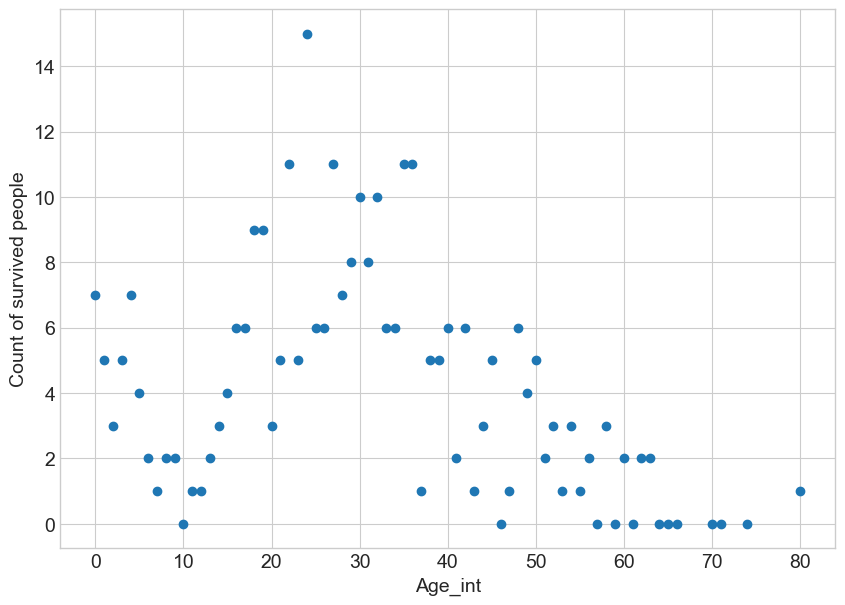

In [4213]:
plt.figure(figsize=(10,7))

plt.scatter(x=data.Age_int, y=data.Survived)

plt.xlabel("Age_int")
plt.ylabel("Count of survived people")

plt.show()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


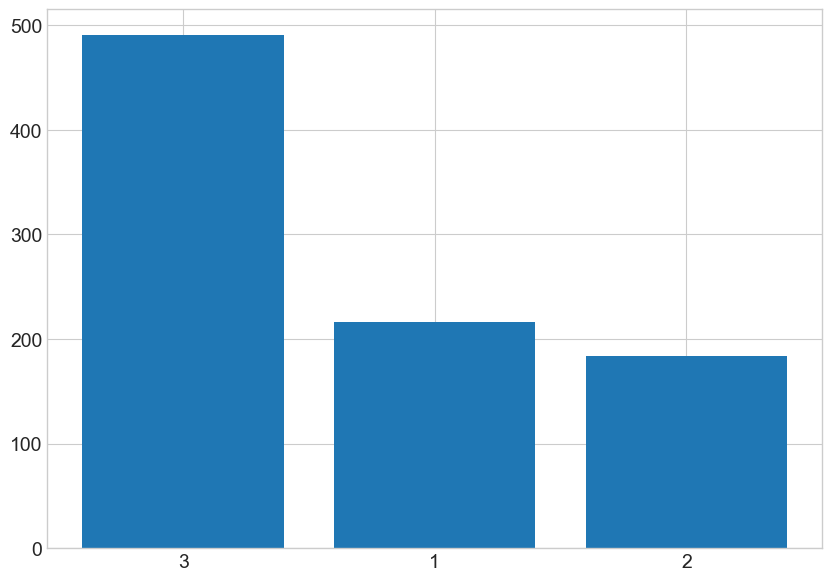

In [4214]:
print(train_data.Pclass.value_counts())

plt.figure(figsize=(10,7))

plt.bar(x=train_data.Pclass.value_counts().index, height=train_data.Pclass.value_counts().values)

plt.show()

<Axes: >

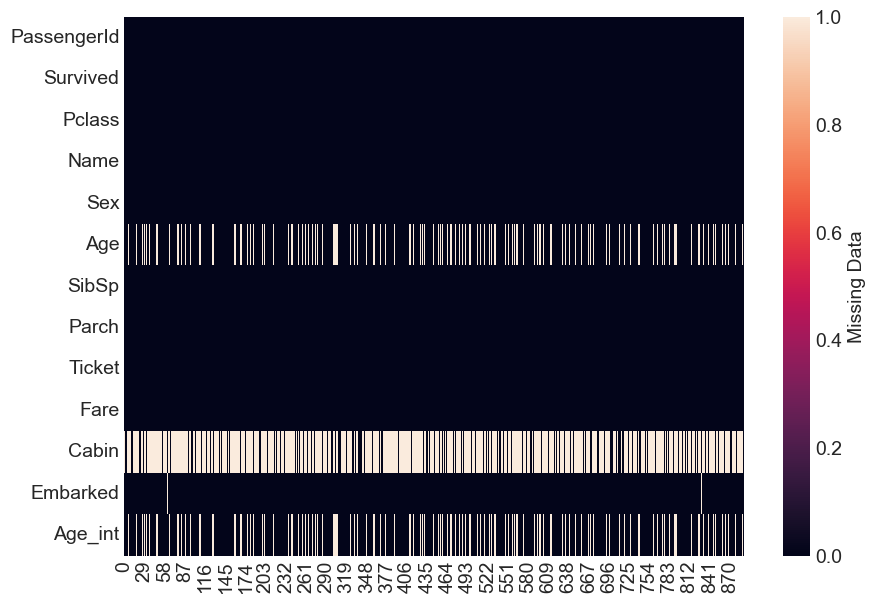

In [4215]:
plt.figure(figsize=(10,7))

sns.heatmap(train_data.isna().transpose(), cbar_kws={"label": "Missing Data"})

In [4216]:
train_data_num_features = train_data.select_dtypes(include=["float16","float32", "float64"])
train_data_num_features.drop("Age_int", axis=1, inplace=True)
train_data_num_features

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


<Figure size 1000x700 with 0 Axes>

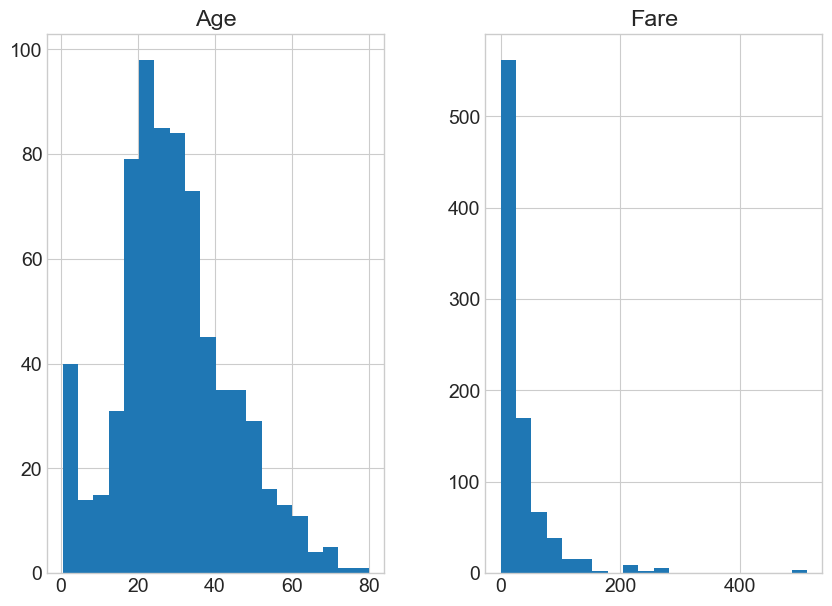

In [4217]:
plt.figure(figsize=(10,7))

# sns.displot(train_data_num_features.Age, bins=20)
# sns.displot(train_data_num_features.Fare, bins=20)
train_data_num_features.hist(figsize=(10,7), bins=20, grid=True)

plt.show()

<Axes: >

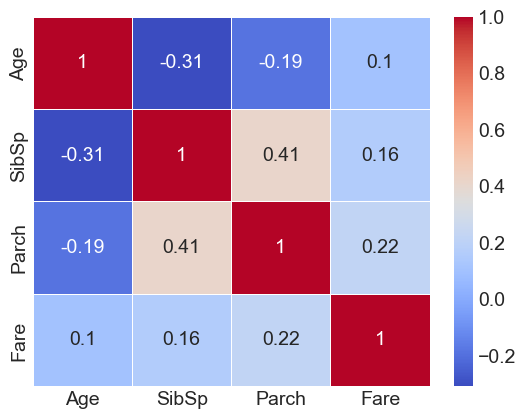

In [4218]:

predictors = [ 'Age', 'SibSp', 'Parch', 'Fare']

corr_matrix = train_data[predictors].corr()
corr_matrix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.1] = 0


sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap="coolwarm")

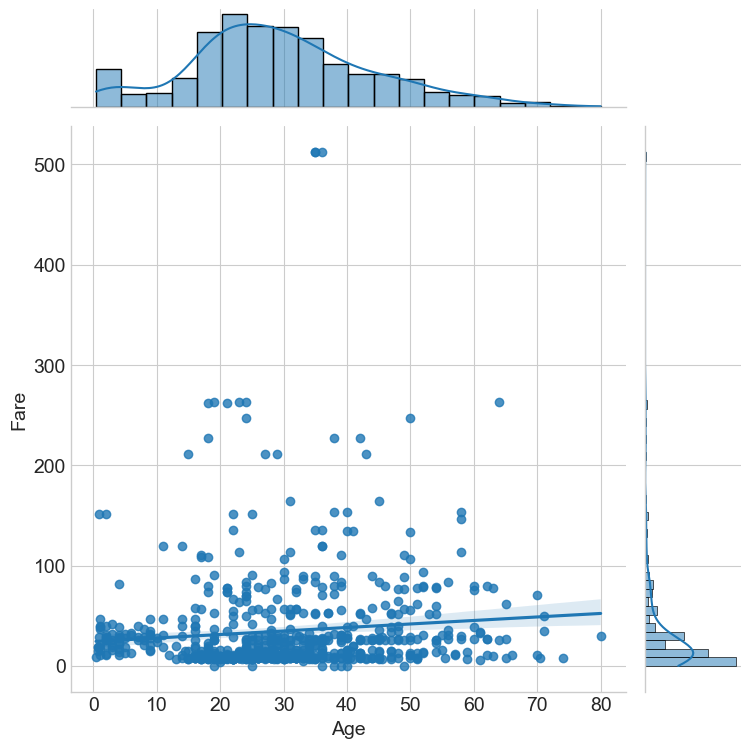

In [4219]:
grid = sns.jointplot(x=train_data.Age, y=train_data.Fare, kind="reg")
grid.fig.set_figwidth(8)
grid.fig.set_figheight(8)

plt.show()

In [4220]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Age_int      714 non-null    float64
dtypes: float64(3), int64(4), object(6)
memory usage: 90.6+ KB


In [4221]:

train_data.describe()

,PassengerId,Survived,Age,SibSp,Parch,Fare,Age_int
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,714.000000
mean,446.000000,0.383838,29.699118,0.523008,0.381594,32.204208,29.679272
std,257.353842,0.486592,14.526497,1.102743,0.806057,49.693429,14.536483
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,20.125000,0.000000,0.000000,7.910400,20.000000
50%,446.000000,0.000000,28.000000,0.000000,0.000000,14.454200,28.000000
75%,668.500000,1.000000,38.000000,1.000000,0.000000,31.000000,38.000000
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200,80.000000


In [4222]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0


In [4223]:
train_data["is_alone"] = 0
train_data.loc[(train_data.SibSp == 0) & (train_data.Parch == 0), "is_alone"] = 1
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [4224]:
train_data.is_alone = train_data.is_alone.astype("object")

In [4225]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Age_int      714 non-null    float64
 13  is_alone     891 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 97.6+ KB


In [4226]:
def func1(x):
  return str(x)

train_data.is_alone.apply(func1)

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: is_alone, Length: 891, dtype: object

In [4227]:
import time
from tqdm import tqdm
tqdm.pandas()

def func2(x):
  time.sleep(0.001)
  return str(x)

train_data.progress_apply(func2, axis=1)

100%|██████████| 891/891 [00:01<00:00, 625.09it/s]


0      PassengerId                          1\nSurviv...
1      PassengerId                                   ...
2      PassengerId                         3\nSurvive...
3      PassengerId                                   ...
4      PassengerId                           5\nSurvi...
                             ...                        
886    PassengerId                      887\nSurvived...
887    PassengerId                             888\nS...
888    PassengerId                                   ...
889    PassengerId                      890\nSurvived...
890    PassengerId                    891\nSurvived  ...
Length: 891, dtype: object

In [4228]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [4229]:
train_data.replace({"is_alone": {0: "no", 1: "yes"}})

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,no
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,no
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,yes
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,no
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,yes
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,yes
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,no
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,yes


In [4230]:
train_data.is_alone.replace({0: "no", 1: "yes"})

0       no
1       no
2      yes
3       no
4      yes
      ... 
886    yes
887    yes
888     no
889    yes
890    yes
Name: is_alone, Length: 891, dtype: object

In [4231]:
train_data.rename(lambda x: str(x) + "_1", axis=1)

,PassengerId_1,Survived_1,Pclass_1,Name_1,Sex_1,Age_1,SibSp_1,Parch_1,Ticket_1,Fare_1,Cabin_1,Embarked_1,Age_int_1,is_alone_1
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [4232]:
df1 = pd.DataFrame({
    'col1': [0, 1, 2],
    'col2': ['zero', 'one', 'two']
}, index=[101, 104, 108])

df1

,col1,col2
101,0,zero
104,1,one
108,2,two


In [4233]:
df2 = pd.DataFrame({
    'col2': ['z', 'c', 'v'],
    'col3': [0, 1, 2],
    'col4': ['zero', 'one', 'two']
}, index=[101, 105, 108])

df2

,col2,col3,col4
101,z,0,zero
105,c,1,one
108,v,2,two


In [4234]:
pd.concat([df1,df2], axis=1)

,col1,col2,col2,col3,col4
101,0.0,zero,z,0.0,zero
104,1.0,one,NaN,NaN,NaN
108,2.0,two,v,2.0,two
105,NaN,NaN,c,1.0,one


In [4235]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [4236]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4237]:
test_outcome

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [4238]:
pd.merge(test_data, test_outcome, on="PassengerId", how="inner", indicator=True)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,_merge
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,both
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1,both
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,both
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,both
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0,both
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,1,both
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,both
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0,both


In [4239]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4240]:
test_data.loc[len(test_data)] = [1600,"3","nureke","male",55,5,2,"345526",6.34566,"C100","Q"]

In [4241]:
test_data.tail(8)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
411,1303,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.00000,C78,Q
412,1304,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.77500,NaN,S
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.05000,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.90000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.25000,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.05000,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.35830,NaN,C
418,1600,3,nureke,male,55.0,5,2,345526,6.34566,C100,Q


In [4242]:
test_data.drop(418, inplace=True)

In [4243]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [4244]:
train_data.Fare.agg(["min", "mean", "max"])

min       0.000000
mean     32.204208
max     512.329200
Name: Fare, dtype: float64

In [4245]:
train_data.agg({"Fare": ["min","mean", "max"],
                "Age_int": ["unique", "median", "mean"]})

,Fare,Age_int
min,0.000000,NaN
mean,32.204208,29.679272
max,512.329200,NaN
unique,NaN,"[22.0, 38.0, 26.0, 35.0, nan, 54.0, 2.0, 27.0,..."
median,NaN,28.0


In [4246]:
train_data.agg({"Fare": ["mean", lambda x: x.value_counts().index[0]],
                "Age_int": ["median", "mean"]})

,Fare,Age_int
mean,32.204208,29.679272
<lambda>,8.050000,NaN
median,NaN,28.000000


In [4247]:
get_mode = lambda x: x.value_counts().index[0]
get_mode.__name__ = "mode"

train_data.agg({"Fare": ["mean", "median", get_mode],
                "Age_int": ["median", get_mode, "mean"],
                "Age": ["median", get_mode, "mean"]})


,Fare,Age_int,Age
mean,32.204208,29.679272,29.699118
median,14.454200,28.000000,28.000000
mode,8.050000,24.000000,24.000000


In [4248]:
train_data_group = train_data.groupby("Pclass")

train_data_group.groups

{'1': [1, 3, 6, 11, 23, 27, 30, 31, 34, 35, 52, 54, 55, 61, 62, 64, 83, 88, 92, 96, 97, 102, 110, 118, 124, 136, 137, 139, 151, 155, 166, 168, 170, 174, 177, 185, 187, 194, 195, 209, 215, 218, 224, 230, 245, 248, 252, 256, 257, 258, 262, 263, 268, 269, 270, 273, 275, 284, 290, 291, 295, 297, 298, 299, 305, 306, 307, 309, 310, 311, 318, 319, 325, 329, 331, 332, 334, 336, 337, 339, 341, 351, 356, 366, 369, 370, 373, 375, 377, 380, 383, 390, 393, 412, 430, 434, 435, 438, 445, 447, ...], '2': [9, 15, 17, 20, 21, 33, 41, 43, 53, 56, 58, 66, 70, 72, 78, 84, 98, 99, 117, 120, 122, 123, 133, 134, 135, 144, 145, 148, 149, 150, 161, 178, 181, 183, 190, 191, 193, 199, 211, 213, 217, 219, 221, 226, 228, 232, 234, 236, 237, 238, 239, 242, 247, 249, 259, 265, 272, 277, 288, 292, 303, 308, 312, 314, 316, 317, 322, 323, 327, 340, 342, 343, 344, 345, 346, 357, 361, 385, 387, 389, 397, 398, 399, 405, 407, 413, 416, 417, 418, 426, 427, 432, 437, 439, 440, 443, 446, 450, 458, 463, ...], '3': [0, 2, 4, 5, 

In [4249]:
def get_NaN_num(x):
  return x.isna().sum()

def get_NaN_num_perc(x):
  return x.isna().sum()/train_data.Cabin.isna().sum() *100

train_data_group.agg({"Age":["median","mean"],
                      "Fare":["median","mean"],
                      "Embarked": [get_mode, "unique", get_NaN_num, get_NaN_num_perc],
                      "Cabin": [get_mode, "unique", get_NaN_num, get_NaN_num_perc]})

Age                Fare            Embarked                  \
       median       mean   median       mean     mode          unique   
Pclass                                                                  
1        37.0  38.233441  60.2875  84.154687        S  [C, S, nan, Q]   
2        29.0  29.877630  14.2500  20.662183        S       [C, S, Q]   
3        24.0  25.140620   8.0500  13.675550        S       [S, Q, C]   

                                       Cabin  \
       get_NaN_num get_NaN_num_perc     mode   
Pclass                                         
1                2         0.291121  B96 B98   
2                0         0.000000      F33   
3                0         0.000000       G6   

                                                                       \
                                                   unique get_NaN_num   
Pclass                                                                  
1       [C85, C123, E46, C103, A6, C23 C25 C27, nan, B...          40   
2                   [nan, D56, F33, E101, F2, F4, D, E77]         168   
3          [nan, G6, F G73, F E69, E10, F G63, E121, F38]         479   

                         
       get_NaN_num_perc  
Pclass                   
1              5.822416  
2             24.454148  
3             69.723435

In [4250]:
train_data.Cabin.isna().sum()

np.int64(687)

In [4251]:
row = train_data.Cabin.isna().sum()
cabin_counts = train_data.Cabin.value_counts()

cabin_counts.loc["NaN_str"] = row

cabin_counts

Cabin
B96 B98          4
G6               4
C23 C25 C27      4
C22 C26          3
F33              3
              ... 
C7               1
C54              1
E36              1
C148             1
NaN_str        687
Name: count, Length: 148, dtype: int64

In [4252]:
pd.DataFrame(cabin_counts)

,count
Cabin,
B96 B98,4
G6,4
C23 C25 C27,4
C22 C26,3
F33,3
...,...
C7,1
C54,1
E36,1


In [4253]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [4254]:

train_data.groupby(["Pclass", "Embarked"]).agg({"Age": "mean"}).unstack("Embarked")


Age                    
Embarked          C        Q          S
Pclass                                 
1         38.027027  38.5000  38.152037
2         22.766667  43.5000  30.386731
3         20.741951  25.9375  25.696552

In [4255]:
train_data.groupby(["Pclass", "Embarked"]).agg({"Age": "mean",
                                                "Fare": "median"}).unstack("Embarked")


Age                         Fare              
Embarked          C        Q          S        C      Q      S
Pclass                                                        
1         38.027027  38.5000  38.152037  78.2667  90.00  52.00
2         22.766667  43.5000  30.386731  24.0000  12.35  13.50
3         20.741951  25.9375  25.696552   7.8958   7.75   8.05

In [4256]:
train_data.pivot_table(index="Pclass",
                       columns="Embarked",
                       values="Age",
                       aggfunc="mean")

Embarked,C,Q,S
Pclass,,,
1,38.027027,38.5000,38.152037
2,22.766667,43.5000,30.386731
3,20.741951,25.9375,25.696552


In [4257]:
train_data_pivot = train_data.pivot_table(index="Pclass",
                       columns="Cabin",
                       values="Age",
                       aggfunc="mean")

train_data_pivot

Cabin,A10,A16,A20,A23,A24,A26,A31,A34,A36,A5,...,E68,E77,E8,F G63,F G73,F2,F33,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,
1,36.0,48.0,49.0,80.0,31.0,56.0,40.0,4.0,39.0,71.0,...,18.0,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,45.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,57.0,NaN,NaN,NaN,13.833333,29.0,2.5,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,42.0,22.0,NaN,NaN,NaN,14.75,NaN


In [4258]:
train_data_pivot_age_mean = train_data_pivot.loc[:,:].mean(axis=1)
train_data_pivot_age_mean

Pclass
1    39.057842
2    28.250000
3    25.450000
dtype: float64

In [4259]:
train_data.pivot_table(index="Pclass",
                       columns="Cabin",
                       values="Age",
                       aggfunc="mean",
                       fill_value=train_data_pivot_age_mean.mean(),
                       margins=True)

Cabin,A10,A16,A20,A23,A24,A26,A31,A34,A36,A5,...,E77,E8,F G63,F G73,F2,F33,F4,G6,T,All
Pclass,,,,,,,,,,,,,,,,,,,,,
1,36.000000,48.000000,49.000000,80.000000,31.000000,56.000000,40.000000,4.000000,39.000000,71.000000,...,30.919281,30.000000,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,45.000000,37.746375
2,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,...,57.000000,30.919281,30.919281,30.919281,13.833333,29.000000,2.500000,30.919281,30.919281,25.266667
3,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,...,30.919281,30.919281,42.000000,22.000000,30.919281,30.919281,30.919281,14.750000,30.919281,21.000000
All,36.000000,48.000000,49.000000,80.000000,31.000000,56.000000,40.000000,4.000000,39.000000,71.000000,...,57.000000,30.000000,42.000000,22.000000,13.833333,29.000000,2.500000,14.750000,45.000000,35.829297


In [4260]:
train_data.pivot_table(index="Pclass",
                       columns="Cabin",
                       values="Age",
                       aggfunc="mean",
                       fill_value=train_data_pivot_age_mean.mean())

Cabin,A10,A16,A20,A23,A24,A26,A31,A34,A36,A5,...,E68,E77,E8,F G63,F G73,F2,F33,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,
1,36.000000,48.000000,49.000000,80.000000,31.000000,56.000000,40.000000,4.000000,39.000000,71.000000,...,18.000000,30.919281,30.000000,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,45.000000
2,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,...,30.919281,57.000000,30.919281,30.919281,30.919281,13.833333,29.000000,2.500000,30.919281,30.919281
3,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,30.919281,...,30.919281,30.919281,30.919281,42.000000,22.000000,30.919281,30.919281,30.919281,14.750000,30.919281


In [4261]:
train_data.pivot_table(index="Pclass",
                       columns="Cabin",
                       values="Fare",
                       aggfunc="count",
                       fill_value=0
                       )

Cabin,A10,A14,A16,A19,A20,A23,A24,A26,A31,A32,...,E8,F E69,F G63,F G73,F2,F33,F38,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,1,1,1,1,...,2,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,3,0,2,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,2,0,0,1,0,4,0


In [4262]:
pd.crosstab(train_data.Pclass, train_data.Cabin)

Cabin,A10,A14,A16,A19,A20,A23,A24,A26,A31,A32,...,E8,F E69,F G63,F G73,F2,F33,F38,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,1,1,1,1,...,2,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,3,0,2,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,2,0,0,1,0,4,0


In [4263]:
train_data.groupby(["Pclass","Cabin"]).agg({"Fare":"count"}).unstack("Cabin").fillna(0)

Fare                                               ...             \
Cabin   A10  A14  A16  A19  A20  A23  A24  A26  A31  A32  ...   E8 F E69   
Pclass                                                    ...              
1       1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  ...  2.0   0.0   
2       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
3       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   1.0   

                                                  
Cabin  F G63 F G73   F2  F33  F38   F4   G6    T  
Pclass                                            
1        0.0   0.0  0.0  0.0  0.0  0.0  0.0  1.0  
2        0.0   0.0  3.0  3.0  0.0  2.0  0.0  0.0  
3        1.0   2.0  0.0  0.0  1.0  0.0  4.0  0.0  

[3 rows x 147 columns]

In [4264]:
train_data.Name

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [4265]:
train_data.Name.str.cat(sep="    ")

'Braund, Mr. Owen Harris    Cumings, Mrs. John Bradley (Florence Briggs Thayer)    Heikkinen, Miss. Laina    Futrelle, Mrs. Jacques Heath (Lily May Peel)    Allen, Mr. William Henry    Moran, Mr. James    McCarthy, Mr. Timothy J    Palsson, Master. Gosta Leonard    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)    Nasser, Mrs. Nicholas (Adele Achem)    Sandstrom, Miss. Marguerite Rut    Bonnell, Miss. Elizabeth    Saundercock, Mr. William Henry    Andersson, Mr. Anders Johan    Vestrom, Miss. Hulda Amanda Adolfina    Hewlett, Mrs. (Mary D Kingcome)     Rice, Master. Eugene    Williams, Mr. Charles Eugene    Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)    Masselmani, Mrs. Fatima    Fynney, Mr. Joseph J    Beesley, Mr. Lawrence    McGowan, Miss. Anna "Annie"    Sloper, Mr. William Thompson    Palsson, Miss. Torborg Danira    Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)    Emir, Mr. Farred Chehab    Fortune, Mr. Charles Alexander    O\'Dwyer, Miss. Ellen "Nellie

In [4266]:
train_data.Name.str.get_dummies(sep=" ")

,"""Andy""","""Annie","""Annie""","""Archie""","""Bessie""","""Carrie""","""Dai""","""Daisy""","""Dolly""","""Ellen""",...,Zillah,"Zimmerman,",de,del,der,"hoef,",of,the,van,y
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
887,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
888,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
889,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4267]:
train_data.Name.isna().sum()

np.int64(0)

In [4268]:
train_data.Ticket.value_counts()

Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64

In [4269]:
train_data.Ticket.str.extract("([0-9]+)")

,0
0,5
1,17599
2,2
3,113803
4,373450
...,...
886,211536
887,112053
888,6607
889,111369


In [4270]:
train_data.Ticket.str.extract("(\d+[0-9]+)")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/2653487876.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_data.Ticket.str.extract("(\d+[0-9]+)")


,0
0,21171
1,17599
2,3101282
3,113803
4,373450
...,...
886,211536
887,112053
888,6607
889,111369


In [4271]:
train_data.Ticket.str.extract("([a-z]+)")


,0
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
886,NaN
887,NaN
888,NaN
889,NaN


In [4272]:
for col in train_data.columns:
    print(f"{col}: {train_data[col].isna().sum()/train_data.shape[0]* 100:.2f}%")

PassengerId: 0.00%
Survived: 0.00%
Pclass: 0.00%
Name: 0.00%
Sex: 0.00%
Age: 19.87%
SibSp: 0.00%
Parch: 0.00%
Ticket: 0.00%
Fare: 0.00%
Cabin: 77.10%
Embarked: 0.22%
Age_int: 19.87%
is_alone: 0.00%


In [4273]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


<Axes: >

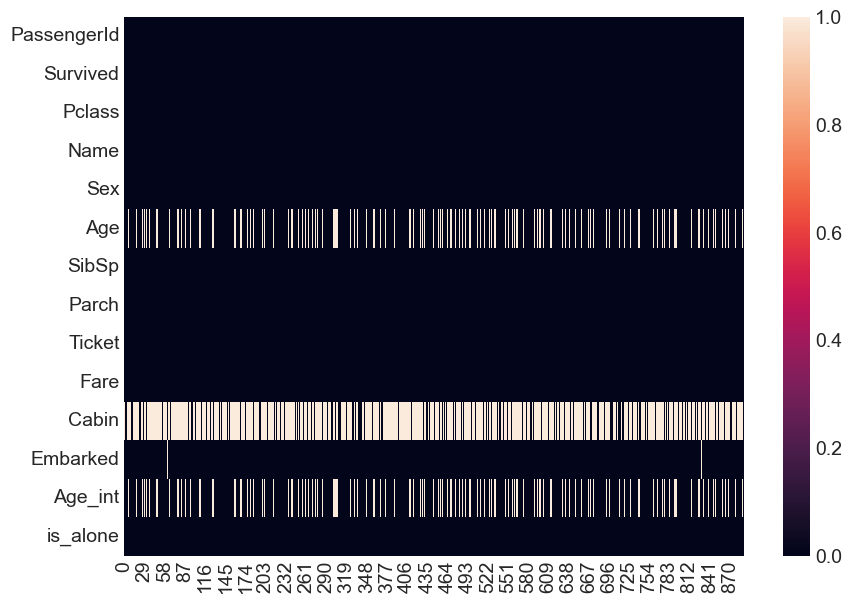

In [4274]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.isna().T)

In [4275]:
train_data.dropna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,54.0,1
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,4.0,0
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,58.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,47.0,0
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,33.0,1
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,56.0,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1


In [4276]:
train_data.dropna(axis=1)

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,0,0,211536,13.0000,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,0,0,112053,30.0000,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,1,2,W./C. 6607,23.4500,0
889,890,1,1,"Behr, Mr. Karl Howell",male,0,0,111369,30.0000,1


In [4277]:
train_data.dropna(how="all", axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [4278]:
train_data.dropna(thresh=train_data.shape[0]//2, axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1


In [4279]:
train_data.dropna(subset=["Age"], axis=0)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,39.0,0
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [4280]:
# predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
# outcome = 'Survived'

# X = pd.get_dummies(train_data[predictors], drop_first=True)
# y = train_data[outcome]

# model_simple = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
# model_simple.fit(X,y,)

In [4281]:
train_data_removed = train_data.dropna(thresh=train_data.shape[0]//2, axis=1)
train_data_removed

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1


In [4282]:
train_data_removed.dropna(thresh=13, axis=0, inplace=True)
train_data_removed

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/4115674139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_removed.dropna(thresh=13, axis=0, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Q,39.0,0
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1


<Axes: >

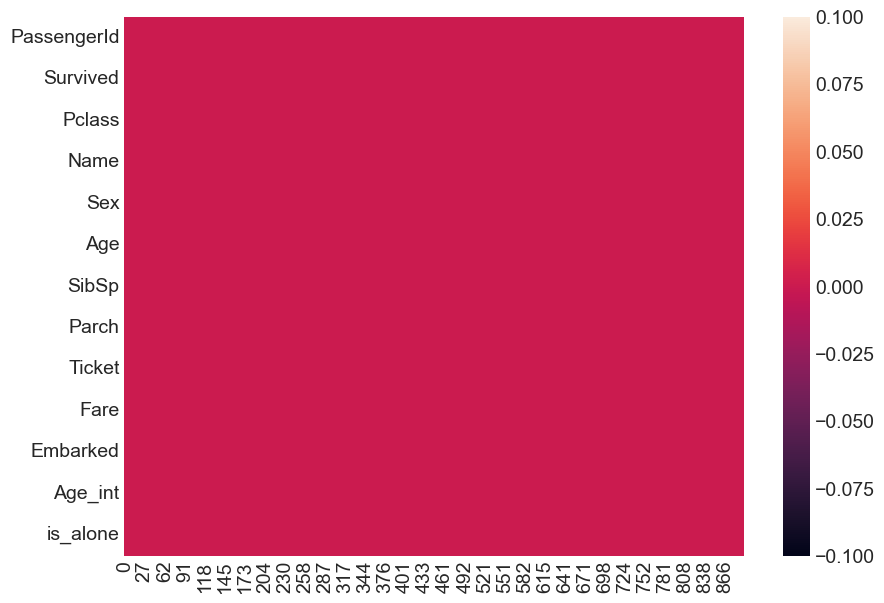

In [4283]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data_removed.isna().T)

In [4284]:

train_data.isna().sum()#.sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
              ... 
Fare             0
Cabin          687
Embarked         2
Age_int        177
is_alone         0
Length: 14, dtype: int64

In [4285]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4286]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
              ... 
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Length: 11, dtype: int64

<Axes: >

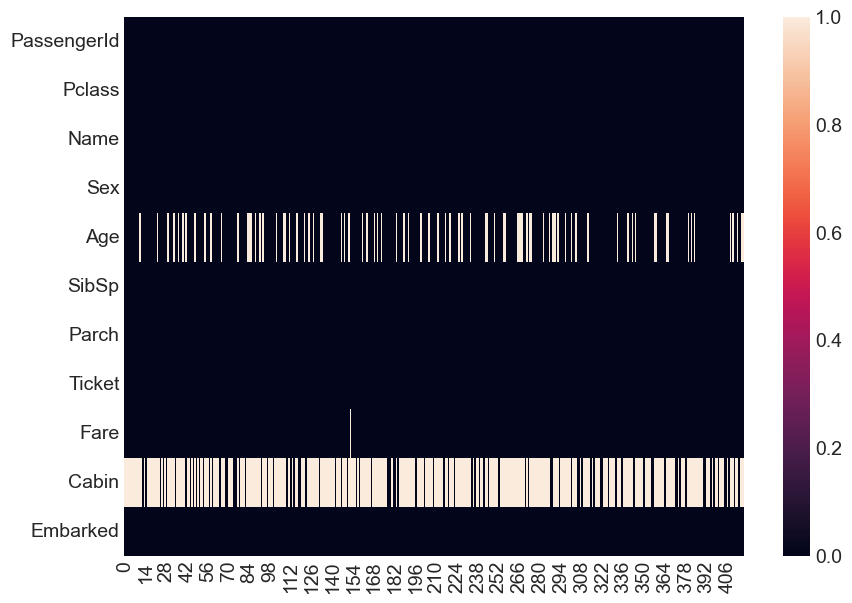

In [4287]:
plt.figure(figsize=(10,7))
sns.heatmap(test_data.isna().T)

In [4288]:
general_data = pd.concat([train_data,test_data])

print(test_data.Age.mean())
print(test_data.Age.median())

30.272590361445783
27.0


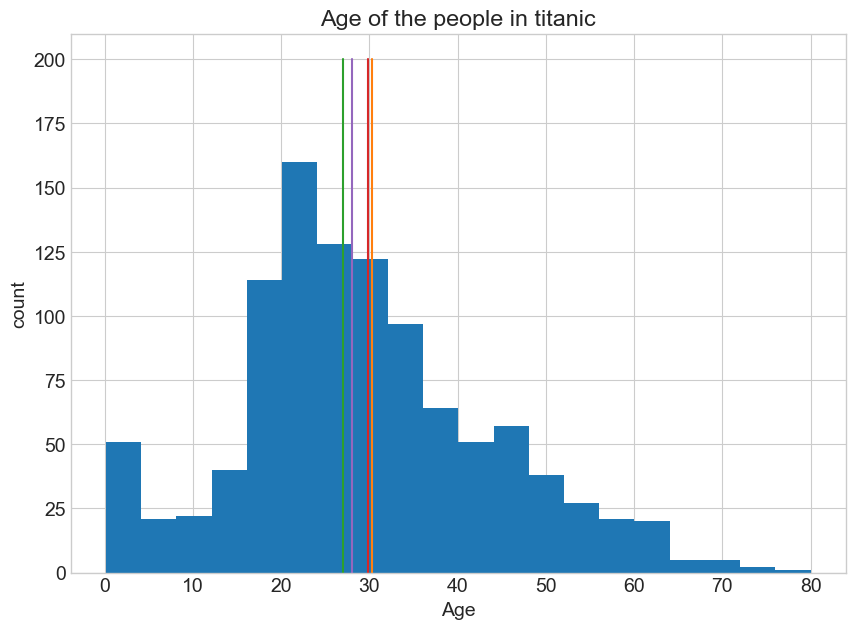

In [4289]:
plt.figure(figsize=(10,7))


plt.hist(pd.concat([train_data.Age, test_data.Age]), bins=20)
plt.plot([test_data.Age.mean(), test_data.Age.mean()], [0, 200])
plt.plot([test_data.Age.median(), test_data.Age.median()], [0, 200])


plt.plot([general_data.Age.mean(), general_data.Age.mean()], [0, 200])
plt.plot([general_data.Age.median(), general_data.Age.median()], [0, 200])

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.show()

In [4290]:
test_data.Age.isna().sum()

np.int64(86)

In [4291]:
test_data["Age_filled"] = 0
test_data.loc[test_data.Age.isna(), "Age_filled"] = 1

test_data.Age.fillna(general_data.Age.median(), inplace=True)

test_data.Fare = test_data.Fare.fillna(general_data.Fare.median())

test_data

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/1264029975.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data.Age.fillna(general_data.Age.median(), inplace=True)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1


In [4292]:
# test_data.Age.fillna(general_data.Age.median(), inplace=True)
# # test_data.Age = test_data.Age.fillna(general_data.Age.median())
# test_data

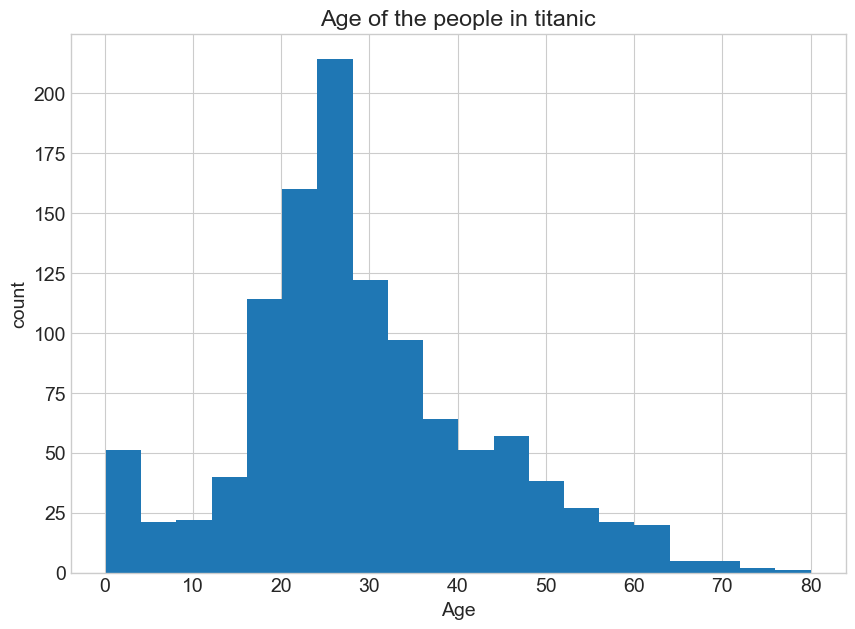

In [4293]:
plt.figure(figsize=(10,7))


plt.hist(pd.concat([train_data.Age, test_data.Age]), bins=20)
# plt.plot([test_data.Age.mean(), test_data.Age.mean()], [0, 200])
# plt.plot([test_data.Age.median(), test_data.Age.median()], [0, 200])


# plt.plot([general_data.Age.mean(), general_data.Age.mean()], [0, 200])
# plt.plot([general_data.Age.median(), general_data.Age.median()], [0, 200])

plt.title("Age of the people in titanic")
plt.xlabel("Age")
plt.ylabel("count")

plt.show()

<Axes: >

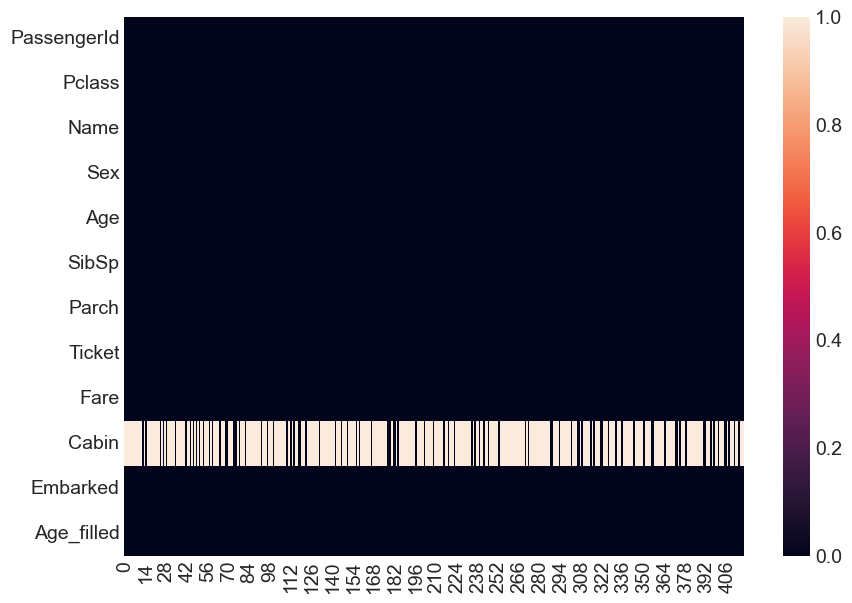

In [4294]:
plt.figure(figsize=(10,7))
sns.heatmap(test_data.isna().T)

In [4295]:

train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


In [4296]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Age_int      714 non-null    float64
 13  is_alone     891 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 97.6+ KB


<Axes: >

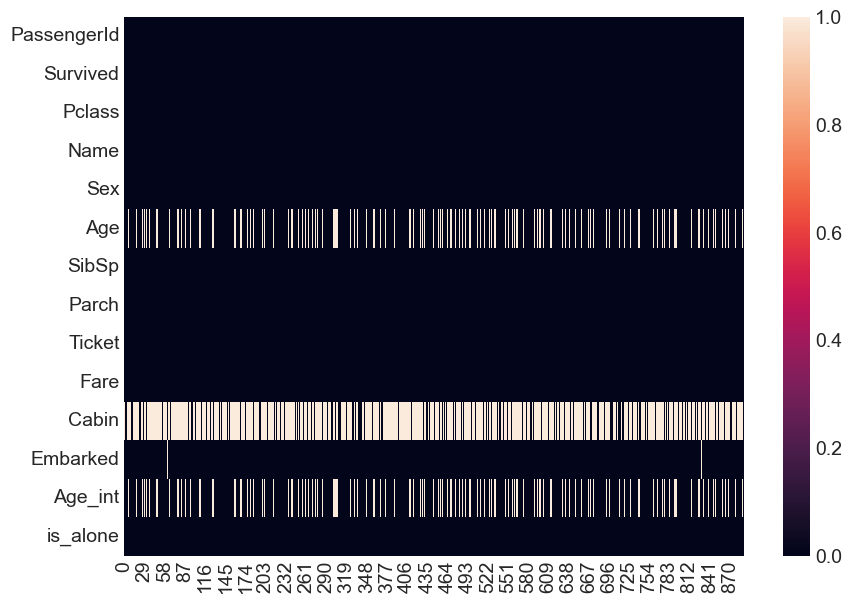

In [4297]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.isna().T)

In [4298]:
train_data_removed

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Q,39.0,0
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1


In [4299]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'

train_data_removed.is_alone = train_data_removed.is_alone.astype(int)


X = pd.get_dummies(train_data_removed[predictors], drop_first=True)
y = train_data_removed[outcome]

model_removed = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_removed.fit(X,y,)


/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/4244844522.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_removed.is_alone = train_data_removed.is_alone.astype(int)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+42
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [4300]:
test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    object 
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Age_filled   418 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 58.6+ KB


In [4301]:
print_metrics(test_outcome.Survived, model_removed.predict(test_data_dummies), "Rows were Removed")

Metrics of Rows were Removed
-----------------------------
Accuracy: 0.8947368421052632
Precision: 0.8417721518987342
Recall: 0.875
Logloss: 3.7940687778018054
ROC-AUC: 0.8905075187969924


In [4302]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked','is_alone']
outcome = 'Survived'


X = pd.get_dummies(train_data_removed[predictors], drop_first=True)
y = train_data_removed[outcome]


model_removed = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_removed.fit(X,y,)


test_data["is_alone"] = [1 if(parch == 0) and (sibsp == 0) else 0 for parch,sibsp in zip(test_data.Parch, test_data.SibSp)]

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)
test_data_dummies

,Age,SibSp,Parch,Fare,is_alone,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,34.5,0,0,7.8292,1,False,True,True,True,False
1,47.0,1,0,7.0000,0,False,True,False,False,True
2,62.0,0,0,9.6875,1,True,False,True,True,False
3,27.0,0,0,8.6625,1,False,True,True,False,True
4,22.0,1,1,12.2875,0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...
413,28.0,0,0,8.0500,1,False,True,True,False,True
414,39.0,0,0,108.9000,1,False,False,False,False,False
415,38.5,0,0,7.2500,1,False,True,True,False,True
416,28.0,0,0,8.0500,1,False,True,True,False,True


In [4303]:
model_removed.coef_[0]
for key,value in enumerate(X.columns):
    print(f"{value}: {model_removed.coef_[0][key]}")

print("-"*50)

print_metrics(test_outcome.Survived, model_removed.predict(test_data_dummies), "Rows were Removed and 'is_alone' feature was used")

Age: -0.04271477469925315
SibSp: -0.5176843883543255
Parch: -0.16724123789110978
Fare: 0.0012006710449980408
is_alone: -0.5383626693875081
Pclass_2: -1.1708504781499167
Pclass_3: -2.313860675364895
Sex_male: -2.58593131216673
Embarked_Q: -0.677636652778554
Embarked_S: -0.3197699501720463
--------------------------------------------------
Metrics of Rows were Removed and 'is_alone' feature was used
-----------------------------
Accuracy: 0.8875598086124402
Precision: 0.8431372549019608
Recall: 0.8486842105263158
Logloss: 4.0527552853792015
ROC-AUC: 0.8792293233082707


In [4304]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1


<Axes: >

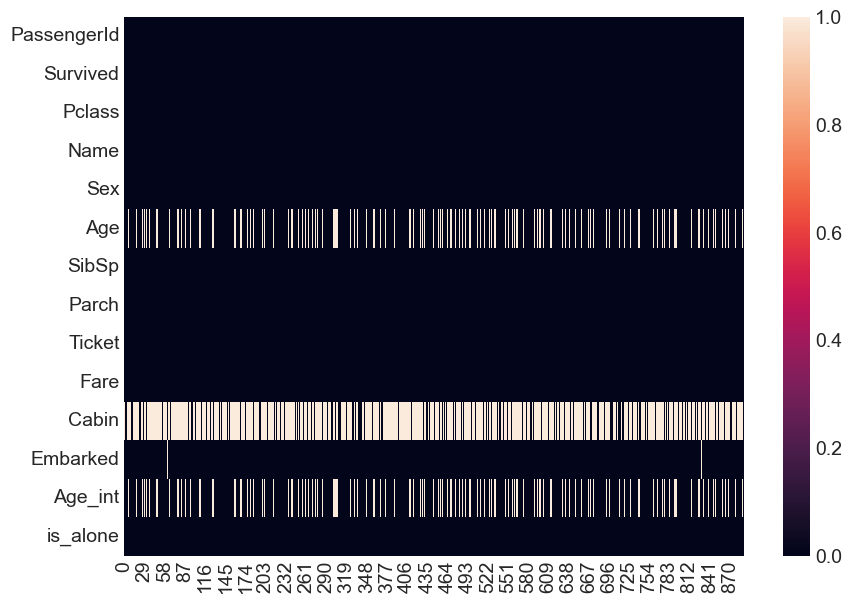

In [4305]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.isna().T)

In [4306]:
train_data["Age_filled"] = 0

train_data.loc[train_data.Age.isna(), "Age_filled"] = 1

train_data.is_alone = train_data.is_alone.astype(int)

train_data_recovered = train_data.drop(columns=["Cabin"])

train_data_recovered

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,NaN,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0


In [4307]:


train_data_recovered.Age.fillna(general_data.Age.median(), inplace=True)

train_data_recovered.Embarked.fillna(general_data.Embarked.mode()[0], inplace=True)


train_data_recovered

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/13664362.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data_recovered.Age.fillna(general_data.Age.median(), inplace=True)
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/13664362.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,NaN,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0


<Axes: >

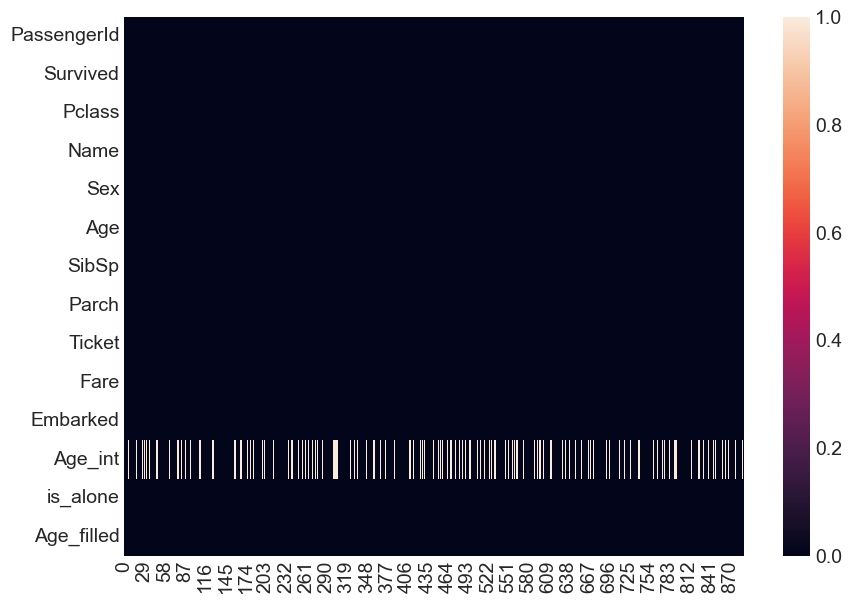

In [4308]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data_recovered.isna().T)

In [4309]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_main = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_main.fit(X,y)

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)
test_data_dummies

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,34.5,0,0,7.8292,False,True,True,True,False
1,47.0,1,0,7.0000,False,True,False,False,True
2,62.0,0,0,9.6875,True,False,True,True,False
3,27.0,0,0,8.6625,False,True,True,False,True
4,22.0,1,1,12.2875,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...
413,28.0,0,0,8.0500,False,True,True,False,True
414,39.0,0,0,108.9000,False,False,False,False,False
415,38.5,0,0,7.2500,False,True,True,False,True
416,28.0,0,0,8.0500,False,True,True,False,True


In [4310]:
print_metrics(test_outcome.Survived, model_main.predict(test_data_dummies), "Data was recovered")

Metrics of Data was recovered
-----------------------------
Accuracy: 0.9449760765550239
Precision: 0.9161290322580645
Recall: 0.9342105263157895
Logloss: 1.9832632247600348
ROC-AUC: 0.9426691729323308


In [4311]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled,is_alone
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1,1
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,1
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1,1


In [4312]:
model_predictions = model_main.predict(test_data_dummies)
submit_file = pd.DataFrame({"PassengerId": test_data.PassengerId,
                            "Survived": model_predictions})

submit_file

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [4313]:
submit_file.to_csv("data/submit_kaggle_file.csv", index=False)

In [4314]:
train_data

/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/IPython/core/displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0


In [4315]:
train_data.Ticket.str.extract("([0-9]+)")

,0
0,5
1,17599
2,2
3,113803
4,373450
...,...
886,211536
887,112053
888,6607
889,111369


In [4316]:
train_data.Ticket.str.extract("(\d+[0-9]+)")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/2653487876.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_data.Ticket.str.extract("(\d+[0-9]+)")


,0
0,21171
1,17599
2,3101282
3,113803
4,373450
...,...
886,211536
887,112053
888,6607
889,111369


In [4317]:
train_data["Ticket_str"] = train_data.Ticket.str.extract("([A-Za-z\.\/0-9]+)")

train_data["Ticket_str"] = [np.nan if ticket.isdigit() else ticket for ticket in train_data["Ticket_str"]]

train_data

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/2161196765.py:1: SyntaxWarning: invalid escape sequence '\.'
  train_data["Ticket_str"] = train_data.Ticket.str.extract("([A-Za-z\.\/0-9]+)")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN


In [4318]:
train_data["Ticket_int"] = train_data.Ticket.str.extract("(\d+[0-9]+)")

train_data

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/37312392.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_data["Ticket_int"] = train_data.Ticket.str.extract("(\d+[0-9]+)")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN,211536
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.,6607
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN,111369


<Axes: >

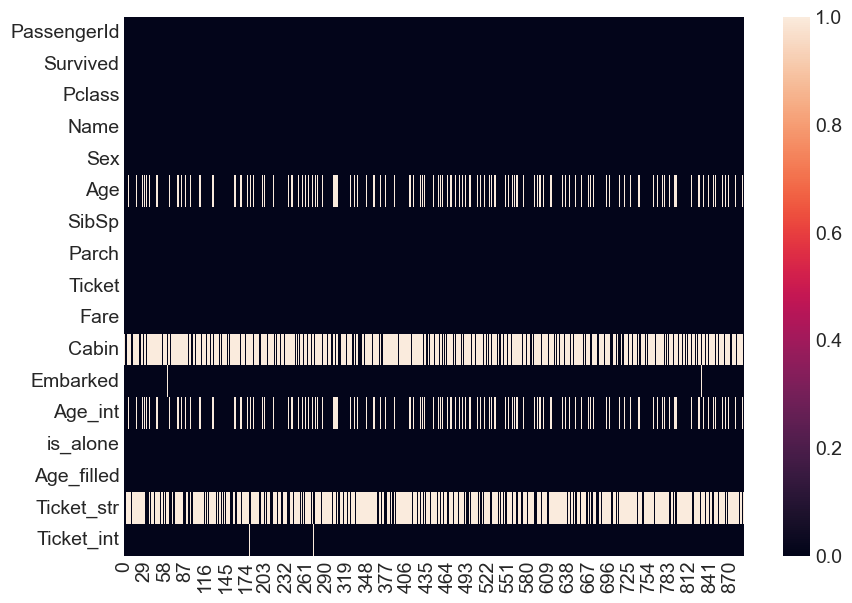

In [4319]:
plt.figure(figsize=(10,7))
sns.heatmap(train_data.isna().T)

In [4320]:
train_data.loc[train_data.Ticket_int.isna()]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,36.0,1,0,LINE,NaN
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,25.0,1,0,LINE,NaN
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,19.0,1,0,LINE,NaN
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,49.0,1,0,LINE,NaN
772,773,0,2,"Mack, Mrs. (Mary)",female,57.0,0,0,S.O./P.P. 3,10.5,E77,S,57.0,1,0,S.O./P.P.,NaN
841,842,0,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5,NaN,S,16.0,1,0,S.O./P.P.,NaN


In [4321]:
train_data.loc[[772,841],["Ticket_int"]] = 3
train_data.loc[train_data.Ticket_int.isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,36.0,1,0,LINE,NaN
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,25.0,1,0,LINE,NaN
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,19.0,1,0,LINE,NaN
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,49.0,1,0,LINE,NaN


In [4322]:
train_data.Ticket_int[~train_data.Ticket_int.isna()]


0        21171
1        17599
2      3101282
3       113803
4       373450
        ...   
886     211536
887     112053
888       6607
889     111369
890     370376
Name: Ticket_int, Length: 887, dtype: object

In [4323]:
train_data.Ticket_int[~train_data.Ticket_int.isna()].astype(int).mean()

np.float64(298328.4171364149)

In [4324]:
train_data.Ticket_int[~train_data.Ticket_int.isna()].mode()

0      1601
1      2343
2    347082
Name: Ticket_int, dtype: object

In [4325]:
train_data.Ticket_int[~train_data.Ticket_int.isna()].value_counts()

Ticket_int
1601       7
347082     7
2343       7
3101295    6
2144       6
          ..
9234       1
19988      1
2693       1
17612      1
370376     1
Name: count, Length: 678, dtype: int64

In [4326]:
train_data.Ticket_int = train_data.Ticket_int.fillna(train_data.Ticket_int[~train_data.Ticket_int.isna()].astype(int).median())
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN,211536
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.,6607
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN,111369


In [4327]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked','Age_filled', "is_alone"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_recovered = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_recovered.fit(X,y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+42
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [4328]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled,is_alone
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1,1
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,1
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1,1


In [4329]:
test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)
print_metrics(test_outcome.Survived, model_recovered.predict(test_data_dummies), "Recovered data and added 'Age_filled','is_alone' features")

Metrics of Recovered data and added 'Age_filled','is_alone' features
-----------------------------
Accuracy: 0.9449760765550239
Precision: 0.910828025477707
Recall: 0.9407894736842105
Logloss: 1.9832632247600348
ROC-AUC: 0.9440789473684212


In [4330]:
test_data["Ticket_int"] = test_data.Ticket.str.extract("(\d+[0-9]+)")

test_data.Ticket_int

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/534419831.py:1: SyntaxWarning: invalid escape sequence '\d'
  test_data["Ticket_int"] = test_data.Ticket.str.extract("(\d+[0-9]+)")


0       330911
1       363272
2       240276
3       315154
4      3101298
        ...   
413       3236
414      17758
415    3101262
416     359309
417       2668
Name: Ticket_int, Length: 418, dtype: object

In [4331]:
pd.concat([train_data, test_data]).reset_index()

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int
0,0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171
1,1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599
2,2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282
3,3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803
4,4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,413,1305,NaN,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,NaN,1,1,NaN,3236
1305,414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,NaN,1,0,NaN,17758
1306,415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,NaN,1,0,NaN,3101262
1307,416,1308,NaN,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,NaN,1,1,NaN,359309


In [4332]:
train_data_recovered

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,NaN,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0


In [4333]:
train_data_recovered["Ticket_int"] = train_data_recovered.Ticket.str.extract("(\d+[0-9]+)")
train_data_recovered

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/1589571751.py:1: SyntaxWarning: invalid escape sequence '\d'
  train_data_recovered["Ticket_int"] = train_data_recovered.Ticket.str.extract("(\d+[0-9]+)")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled,Ticket_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0,211536
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,NaN,0,1,6607
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0,111369


In [4334]:
train_data_recovered.Ticket_int.isna().sum()

np.int64(6)

In [4335]:
test_data.Ticket_int.isna().sum()

np.int64(2)

In [4336]:
mean_ticket_int = train_data_recovered.loc[~train_data_recovered.Ticket_int.isna()].Ticket_int.astype(int).mean()
median_ticket_int = train_data_recovered.loc[~train_data_recovered.Ticket_int.isna()].Ticket_int.astype(int).median()

print(mean_ticket_int)
print(median_ticket_int)

299002.5988700565
112379.0


In [4337]:
train_data_recovered.Ticket_int.fillna(median_ticket_int, inplace=True)
train_data_recovered

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_63189/1435883998.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data_recovered.Ticket_int.fillna(median_ticket_int, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled,Ticket_int
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0,21171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0,17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0,3101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,27.0,1,0,211536
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,19.0,1,0,112053
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,NaN,0,1,6607
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,26.0,1,0,111369


In [4338]:
train_data_recovered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  Age_int      714 non-null    float64
 12  is_alone     891 non-null    int64  
 13  Age_filled   891 non-null    int64  
 14  Ticket_int   891 non-null    object 
dtypes: float64(3), int64(6), object(6)
memory usage: 104.5+ KB


In [4339]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 417
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    object 
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Age_filled   418 non-null    int64  
 12  is_alone     418 non-null    int64  
 13  Ticket_int   416 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 65.1+ KB


In [4340]:
test_data.Ticket_int.fillna(median_ticket_int, inplace=True)
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled,is_alone,Ticket_int
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1,330911
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0,363272
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1,240276
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1,315154
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0,3101298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1,1,3236
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,1,17758
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,1,3101262
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1,1,359309


In [4341]:
train_data_recovered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  Age_int      714 non-null    float64
 12  is_alone     891 non-null    int64  
 13  Age_filled   891 non-null    int64  
 14  Ticket_int   891 non-null    object 
dtypes: float64(3), int64(6), object(6)
memory usage: 104.5+ KB


In [4342]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 417
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    object 
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Age_filled   418 non-null    int64  
 12  is_alone     418 non-null    int64  
 13  Ticket_int   418 non-null    object 
dtypes: float64(2), int64(5), object(7)
memory usage: 65.1+ KB


In [4343]:
test_data.Ticket_int = test_data.Ticket_int.astype(int)
train_data_recovered.Ticket_int = train_data_recovered.Ticket_int.astype(int)


In [4344]:
train_data_recovered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  Age_int      714 non-null    float64
 12  is_alone     891 non-null    int64  
 13  Age_filled   891 non-null    int64  
 14  Ticket_int   891 non-null    int64  
dtypes: float64(3), int64(7), object(5)
memory usage: 104.5+ KB


In [4345]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 417
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    object 
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Age_filled   418 non-null    int64  
 12  is_alone     418 non-null    int64  
 13  Ticket_int   418 non-null    int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 65.1+ KB


In [4346]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Ticket_int","is_alone","Age_filled"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_recovered_new_features = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_recovered_new_features.fit(X,y)

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)

print_metrics(test_outcome.Survived, model_recovered_new_features.predict(test_data_dummies), 'Added "Ticket_int","is_alone","Age_filled" feature')

Metrics of Added "Ticket_int","is_alone","Age_filled" feature
-----------------------------
Accuracy: 0.65311004784689
Precision: 0.547945205479452
Recall: 0.2631578947368421
Logloss: 12.503181199574131
ROC-AUC: 0.569548872180451


In [4347]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Ticket_int","is_alone","Age_filled"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_recovered_new_features = LogisticRegression(penalty='l1', C=1e42, solver='liblinear')
model_recovered_new_features.fit(X,y)

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)

print_metrics(test_outcome.Survived, model_recovered_new_features.predict(test_data_dummies), 'Added "Ticket_int","is_alone","Age_filled" features, l1')

Metrics of Added "Ticket_int","is_alone","Age_filled" features, l1
-----------------------------
Accuracy: 0.9425837320574163
Precision: 0.9155844155844156
Recall: 0.9276315789473685
Logloss: 2.069492060619167
ROC-AUC: 0.9393796992481204


In [4348]:
train_data.Cabin.isna().sum()/(train_data.Cabin.isna().sum() + train_data.Cabin.count())

np.float64(0.7710437710437711)

In [4349]:
test_data.Cabin.isna().sum()/(test_data.Cabin.isna().sum() + test_data.Cabin.count())


np.float64(0.7822966507177034)

In [4350]:
# train_data["Cabin_str"] =
train_data["Cabin_str"] = train_data.Cabin.str.extract("([a-zA-Z]+)")
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_int,is_alone,Age_filled,Ticket_str,Ticket_int,Cabin_str
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0,0,0,A/5,21171,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0,0,0,PC,17599,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0,1,0,STON/O2.,3101282,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0,0,0,NaN,113803,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0,1,0,NaN,373450,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,27.0,1,0,NaN,211536,NaN
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,19.0,1,0,NaN,112053,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,NaN,0,1,W./C.,6607,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,26.0,1,0,NaN,111369,C


In [4351]:
test_data["Cabin_str"] = test_data.Cabin.str.extract("([a-zA-Z]+)")
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_filled,is_alone,Ticket_int,Cabin_str
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1,330911,NaN
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0,363272,NaN
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1,240276,NaN
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1,315154,NaN
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0,3101298,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,28.0,0,0,A.5. 3236,8.0500,NaN,S,1,1,3236,NaN
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0,1,17758,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,1,3101262,NaN
416,1308,3,"Ware, Mr. Frederick",male,28.0,0,0,359309,8.0500,NaN,S,1,1,359309,NaN


In [4354]:
train_data.Cabin_str.value_counts()

Cabin_str
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

In [4362]:
train_data_recovered["Cabin_str"] = train_data.Cabin_str
train_data_recovered.loc[train_data_recovered.Cabin_str == "T", "Cabin_str"] = "C"
train_data_recovered.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_int,is_alone,Age_filled,Ticket_int,Cabin_str
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,22.0,0,0,21171,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,38.0,0,0,17599,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,26.0,1,0,3101282,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,35.0,0,0,113803,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,35.0,1,0,373450,NaN


In [4364]:
predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',"Cabin_str"]
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors], drop_first=True)
y = train_data_recovered[outcome]


model_recovered_new_features = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
model_recovered_new_features.fit(X,y)

test_data_dummies = pd.get_dummies(test_data[predictors], drop_first=True)

print_metrics(test_outcome.Survived, model_recovered_new_features.predict(test_data_dummies), 'Added "Cabin_str"')

Metrics of Added "Cabin_str"
-----------------------------
Accuracy: 0.9282296650717703
Precision: 0.8860759493670886
Recall: 0.9210526315789473
Logloss: 2.5868650757739586
ROC-AUC: 0.9266917293233082


In [4360]:
test_data.Cabin_str.value_counts()

Cabin_str
C    35
B    18
D    13
E     9
F     8
A     7
G     1
Name: count, dtype: int64

In [ ]:
pd.DataFrame({"coef": model_recovered_new_features.coef_[0],
              "name": X.columns})

,coef,name
0,-0.040542,Age
1,-0.325747,SibSp
2,-0.103044,Parch
3,0.002787,Fare
4,-0.487609,Pclass_2
...,...,...
10,0.135305,Cabin_str_C
11,1.165925,Cabin_str_D
12,1.689365,Cabin_str_E
13,1.197045,Cabin_str_F


In [4395]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


predictors = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
outcome = 'Survived'


X = pd.get_dummies(train_data_recovered[predictors])
y = train_data_recovered[outcome]

model_knn = KNeighborsClassifier(n_neighbors=15)
model_knn.fit(X,y)


test_data_dummies = pd.get_dummies(test_data[predictors])
print_metrics(test_outcome.Survived, model_knn.predict(test_data_dummies), 'KNN model')

Metrics of KNN model
-----------------------------
Accuracy: 0.6722488038277512
Precision: 0.5581395348837209
Recall: 0.47368421052631576
Logloss: 11.813350512701076
ROC-AUC: 0.6296992481203006
